# New Zealand Crash Analysis System

## Introduction

This notebook presents an analysis of crash severity using a subset of the New Zealand Crash Analysis System dataset. There is a considerable volume of data (from my student perspective): 705824 rows and 79 columns.

The workflow begins with targeted feature engineering capturing:

- environmental conditions
- road characteristics
- vehicle involvement
- injury indicators

This is followed by correlation‑guided feature selection to isolate the most informative predictors. Exploratory visualisations establish the real‑world patterns behind severe crashes and provide the context for modelling.

To assess how predictable severity outcomes are, the notebook evaluates three lightweight, interpretable classifiers:

- Logistic Regression
- Linear SVM
- Gaussian Naïve Bayes


## Libraries

In [253]:
# libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, make_scorer
)
from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)


In [254]:
# Setup for PNG export functionality
import os

# Create plots directory with error handling
try:
    os.makedirs('plots', exist_ok=True)
    print("Plots directory ready")
except Exception as e:
    print(f"Warning: Could not create plots directory: {e}")

Plots directory ready


## Functions

In [255]:
def load_data(file_path):
    """
    Load data from a CSV file into a pandas DataFrame.
    
    This function reads data from a CSV file and provides immediate feedback
    on the loading success along with a preview of the data.
    
    Parameters
    ----------
    file_path : str
        Path to the CSV file to be loaded.
        
    Returns
    -------
    pandas.DataFrame or None
        DataFrame containing the loaded data if successful, None if failed.
        
    Notes
    -----
    - Displays the first 5 rows of the dataset upon successful loading
    - Prints error message if loading fails
    - Uses pandas.read_csv() with default parameters
    """
    try:
        df = pd.read_csv(file_path)
        print("Dataset loaded successfully.")
        display(df.head())
        return df
    except Exception as e:
        print(f"Failed to load data: {e}")
        return None

In [256]:
def inspect_dataframe(df):
    """
    Perform comprehensive inspection of a pandas DataFrame.
    
    This function provides a thorough overview of the DataFrame including
    shape, data preview, data types, statistical summaries, and data quality
    checks to help understand dataset characteristics.
    
    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame to inspect.
        
    Returns
    -------
    None
        Prints inspection results directly to console.
        
    Notes
    -----
    - Displays DataFrame shape (rows, columns)
    - Shows first and last 5 rows of data
    - Provides data type information and memory usage
    - Reports statistical summary for numeric columns
    - Checks for duplicate rows
    - Identifies missing values with counts and percentages
    """
    # Does a brief inspection of a dataframe
    print("-" * 30)
    # Shape of the dataframe
    # Basic shape
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    
    print("\n" +"-" * 30)
    # Display the first few rows
    print("\nHead of the DataFrame:")
    display(df.head())
    
    print("\n" +"-" * 30)
    # Display the last few rows
    print("\nTail of the DataFrame:")
    display(df.tail())
    
    print("\n" +"-" * 30)
    # DataFrame info
    print("\nDataFrame Info:")
    df.info()
    
    print("\n" +"-" * 30)
    # Statistical description
    print("\nStatistical Description:")
    display(df.describe())
    
    print("\n" +"-" * 30)
    # Check for duplicates
    duplicates = df.duplicated().sum()
    print(f"\nNumber of duplicate rows: {duplicates}")

    print("\n" +"-" * 30)
    # Check for null values
    print("\nNull Values Count:")
    missing = (
    df.isnull()
      .sum()
      .reset_index()
      .rename(columns={"index": "column", 0: "number_missing"})
    )

    missing = missing[missing["number_missing"] > 0]
    missing["percent_missing"] = (missing["number_missing"] / len(df)) * 100
    
    display(missing)

In [257]:
def replace_string_nulls(df):
    """
    Replace string representations of null values with pandas NA.
    
    This function identifies and replaces common string representations
    of missing data with proper pandas NA values for consistent null handling
    during data analysis and preprocessing.
    
    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame to process.
        
    Returns
    -------
    pandas.DataFrame
        DataFrame with string null representations replaced with pd.NA.
        
    Notes
    -----
    - Only processes object/string columns
    - Replaces: "Null", "null", "NULL", " Null ", " null "
    - Uses pandas.NA for consistent null representation
    - Returns a new DataFrame (does not modify original)
    """
    return df.apply(
        lambda col: col.replace(
            to_replace=["Null", "null", "NULL", " Null ", " null "],
            value=pd.NA
        )
        if col.dtype == "object" or pd.api.types.is_string_dtype(col)
        else col
    )

In [258]:
def combine_weather(weatherA, weatherB):
    """
    Combine weatherA and weatherB into a single label.

    Rules:
    - If both are present → "A / B"
    - If only one is present → that one
    - If both are missing → ""
    """
    a = weatherA if pd.notnull(weatherA) else None
    b = weatherB if pd.notnull(weatherB) else None

    if a and b:
        return f"{a} / {b}"
    if a:
        return a
    if b:
        return b
    return ""


In [259]:
def show_countplot(df, col, title, figsize=(10,6), filename_prefix=None):
    """
    Create and display a horizontal count plot for categorical data.
    
    This function generates a seaborn count plot to visualize the frequency
    distribution of categorical variables, ordered alphabetically/numerically.
    
    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame containing the data to plot.
    col : str
        Name of the column to create count plot for.
    title : str
        Title for the plot.
    figsize : tuple, optional
        Figure size as (width, height) in inches. Default is (10, 6).
    filename_prefix : str, optional
        Prefix for saved PNG filename. If None, plot is not saved.
        
    Returns
    -------
    None
        Displays the plot and optionally saves to file.
        
    Notes
    -----
    - Creates horizontal bar plot ordered alphabetically/numerically
    - Automatically drops NA/null values before plotting
    - Saves to 'plots/' directory if filename_prefix provided
    - Uses 300 DPI and tight layout for saved files
    """
    data = df[col].dropna()

    plt.figure(figsize=figsize)
    sns.countplot(
        data=df,
        y=col,
        order=sorted(data.unique())
    )
    plt.title(title)
    plt.xlabel("Count")
    plt.ylabel(col)
    
    # Save plot if filename_prefix provided
    if filename_prefix:
        try:
            safe_column = col.replace(' ', '_').lower()
            filename = f"plots/{filename_prefix}{safe_column}_distribution.png"
            plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
        except Exception as e:
            print(f"Warning: Could not save plot {title}: {e}")
    
    plt.show()

In [260]:
def plot_lower_corr(df, cols, figsize=(10, 8), cmap="coolwarm", filename_prefix=None):
    """
    Plot a strict lower-triangle correlation heatmap for selected columns.
    
    Parameters
    ----------
    df : pandas.DataFrame
        The dataframe containing your data.
    cols : list
        List of column names to include in the correlation matrix.
    figsize : tuple
        Figure size for the plot.
    cmap : str
        Colormap for the heatmap.
    filename_prefix : str, optional
        Prefix for saved PNG filename.
    """
    
    corr = df[cols].corr()
    
    # Strict upper triangle mask (diagonal included)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=0)
    
    plt.figure(figsize=figsize)
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        cmap=cmap,
        square=True
    )
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    
    if filename_prefix:
        try:
            filename = f"plots/{filename_prefix}correlation_heatmap.png"
            plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
        except Exception as e:
            print(f"Warning: Could not save correlation heatmap: {e}")
    
    plt.show()


In [261]:
def evaluate_model(name, model, X_test, y_test, y_proba=None):
    """
    Evaluate binary classification model performance using multiple metrics.
    
    This function computes and displays comprehensive evaluation metrics
    including accuracy, precision, recall, F1-score, ROC-AUC, classification
    report, and confusion matrix for binary classification models.
    
    Parameters
    ----------
    name : str
        Name identifier for the model being evaluated.
    model : sklearn estimator
        Trained machine learning model with predict method.
    X_test : array-like
        Test features for prediction.
    y_test : array-like
        True binary labels for evaluation.
    y_proba : array-like, optional
        Predicted probabilities for positive class. Required for ROC-AUC calculation.
        
    Returns
    -------
    dict
        Dictionary containing evaluation metrics:
        - model: Model name
        - accuracy: Overall accuracy score
        - precision: Precision score
        - recall: Recall score
        - f1: F1-score
        - roc_auc: ROC-AUC score (NaN if y_proba not provided)
        - classification_report: Detailed sklearn classification report dict
        - confusion_matrix: Confusion matrix array
        
    Notes
    -----
    - Prints formatted evaluation results to console
    - Assumes binary classification (positive class = 1)
    - ROC-AUC requires probability predictions for calculation
    """
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    if y_proba is None:
        roc = np.nan
    else:
        roc = roc_auc_score(y_test, y_proba)
    
    # Reports
    cls_report = classification_report(y_test, y_pred, output_dict=False)
    cls_report_dict = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    
    # Print nicely
    print(f"=== {name} ===")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("ROC-AUC  :", roc)
    print("\nClassification report:\n", cls_report)
    print("Confusion matrix:\n", cm)
    
    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc,
        "classification_report": cls_report_dict,
        "confusion_matrix": cm
    }

In [262]:
def plot_confusion_matrix(cm, labels=[0, 1], title="Confusion Matrix", filename_prefix=None):
    """
    Create and display a confusion matrix heatmap for classification results.
    
    This function generates a visually appealing confusion matrix using seaborn
    heatmap to evaluate classification model performance and identify
    misclassification patterns.
    
    Parameters
    ----------
    cm : array-like
        Confusion matrix array from sklearn.metrics.confusion_matrix.
    labels : list, optional
        Class labels for display on axes. Default is [0, 1] for binary classification.
    title : str, optional
        Title for the confusion matrix plot. Default is "Confusion Matrix".
    filename_prefix : str, optional
        Prefix for saved PNG filename. If None, plot is not saved.
        
    Returns
    -------
    None
        Displays the confusion matrix plot and optionally saves to file.
        
    Notes
    -----
    - Uses 'Blues' colormap for professional appearance
    - Displays integer counts in each cell (fmt="d")
    - Saves to 'plots/' directory if filename_prefix provided
    - Automatically sanitizes title for safe filename generation
    - Uses 300 DPI and tight layout for saved files
    """
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    
    if filename_prefix:
        try:
            safe_title = title.lower().replace(' ', '_').replace('—', '_').replace('ï', 'i').replace('ë', 'e')
            filename = f"plots/{filename_prefix}{safe_title}.png"
            plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
        except Exception as e:
            print(f"Warning: Could not save confusion matrix: {e}")
    
    plt.show()

In [263]:
def create_bivariate_plot(df, plot_type, title="", figsize=(10, 6), filename_prefix=None, 
                         participant_cols=None, severity_col="severity_binary"):
    """
    Create bivariate exploratory data analysis plots for crash analysis.
    
    This function supports two specific plot types:
    - Participant stacked: Percentage breakdown of severity by participant type
    - Speed stacked: Percentage breakdown of severity by effective speed limit
    
    Parameters
    ----------
    df : pandas.DataFrame
        The dataframe containing the crash analysis data
    plot_type : str
        Type of plot to create. Options:
        - 'participant_stacked': Stacked percentage chart showing severity distribution by participant type
        - 'speed_stacked': Stacked percentage chart showing severity distribution by speed limit
    title : str
        Descriptive title for the plot
    figsize : tuple, optional
        Figure size as (width, height) in inches. Default is (10, 6)
    filename_prefix : str, optional
        Prefix for saved PNG filename. If None, plot is not saved
    participant_cols : list, optional
        List of participant column names (required for participant_stacked)
    severity_col : str, optional
        Name of the binary severity column. Default is "severity_binary"
        
    Returns
    -------
    None
        Displays the plot and optionally saves to 'plots/' directory
        
    Raises
    ------
    ValueError
        If participant_cols is None for participant_stacked plot type
        If unsupported plot_type is specified
    """
    
    # PARTICIPANT STACKED: Percentage breakdown of severity by participant type    
    if plot_type == "participant_stacked":
        if participant_cols is None:
            raise ValueError("participant_cols is required for participant_stacked plot")
        
        # Calculate raw counts for severe and non-severe crashes
        counts = pd.DataFrame({
            "severe": df[participant_cols].multiply(df[severity_col], axis=0).sum(),
            "non_severe": df[participant_cols].multiply(1 - df[severity_col], axis=0).sum()
        })
        
        # Convert to percentages for each participant type (row-wise normalization)
        percent = counts.div(counts.sum(axis=1), axis=0)
        
        # Sort alphabetically by participant type (descending to show ascending in horizontal plot)
        percent = percent.sort_index(ascending=False)
        
        # Create stacked horizontal bar chart
        fig, ax = plt.subplots(figsize=figsize)
        percent.plot(
            kind="barh",
            stacked=True,
            ax=ax,
            color=['steelblue', 'orange']
        )
        
        plt.title(title)
        plt.xlabel("Percentage")
        plt.ylabel("Participant Type")
        
        # Add informative legend
        ax.legend(
            title="Severity",
            loc="lower right",
            frameon=True
        )
        
    # SPEED STACKED: Percentage breakdown of severity by effective speed limit
    elif plot_type == "speed_stacked":
        # Create percentage breakdown of severe vs non-severe crashes by effective speed limit
        speed_counts = df.groupby('effective_speed_limit')[severity_col].value_counts().unstack(fill_value=0)
        speed_counts.columns = ['non_severe', 'severe']
        
        # Convert to percentages for each speed limit (row-wise normalization)
        speed_percent = speed_counts.div(speed_counts.sum(axis=1), axis=0)
        
        # Sort by speed limit (descending to show ascending in horizontal plot)
        speed_percent = speed_percent.sort_index(ascending=False)
        
        # Create stacked horizontal bar chart
        fig, ax = plt.subplots(figsize=figsize)
        speed_percent.plot(
            kind="barh",
            stacked=True,
            ax=ax,
            color=['steelblue', 'orange']
        )
        
        plt.title(title)
        plt.xlabel("Percentage")
        plt.ylabel("Effective Speed Limit")
        
        # Add informative legend
        ax.legend(
            title="Severity",
            loc="lower right",
            frameon=True,
            labels=['Non-Severe', 'Severe']
        )
        
    else:
        raise ValueError(f"Unsupported plot_type: {plot_type}. Supported types: 'participant_stacked', 'speed_stacked'")
    
    # SAVE FUNCTIONALITY: Generate publication-quality PNG files
    if filename_prefix and title:
        try:
            # Create filesystem-safe filename from title
            safe_title = (title.lower()
                         .replace(' ', '_')         # Spaces to underscores
                         .replace('/', '_')         # Forward slashes
                         .replace('—', '_')         # Em dashes
                         .replace('-', '_')         # Hyphens
                         .replace('&', 'and')       # Ampersands
                         .replace('%', 'percent'))  # Percent symbols
            
            filename = f"plots/{filename_prefix}{safe_title}.png"
            plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✅ Plot saved as {filename}")
        except Exception as e:
            print(f"Warning: Could not save plot '{title}': {e}")
    
    plt.show()

In [264]:
def summarise_model_results(results_df):
    """
    Produce a clean comparison table with:
      - Model
      - Accuracy
      - Precision
      - Recall
      - F1-Score
      - ROC-AUC

    Ignores nested structures like classification_report and confusion_matrix.
    Returns a tidy DataFrame ready for display or export.
    """

    cols = ["model", "accuracy", "precision", "recall", "f1", "roc_auc"]

    # Filter only the columns we need (in case extra fields exist)
    summary = results_df[cols].copy()

    # Rename for presentation clarity
    summary = summary.rename(columns={
        "model": "Model",
        "accuracy": "Accuracy",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1-Score",
        "roc_auc": "ROC-AUC"
    })

    return summary


In [265]:
# Create and save performance table with gradient coloring
def create_performance_table_image(summary_df, filename="16_model_performance_table.png"):
    """
    Create a performance comparison table with gradient coloring for model evaluation.
    
    This function generates a visually appealing table that displays model performance
    metrics with color-coded cells. Performance values are normalized across all models
    and metrics, with green indicating better performance and red indicating worse
    performance. The table is saved as a high-resolution PNG image.
    
    Parameters
    ----------
    summary_df : pandas.DataFrame
        DataFrame containing model performance metrics. Expected to have:
        - First column: Model names (non-numeric)
        - Remaining columns: Numeric performance metrics (accuracy, precision, etc.)
    filename : str, optional
        Output filename for the saved PNG image. Default is "16_model_performance_table.png".
        
    Returns
    -------
    None
        Displays the table plot and saves to 'plots/' directory.
        
    Notes
    -----
    - Uses min-max normalization across entire numeric matrix for consistent scaling
    - Red-Yellow-Green (RdYlGn) colormap with 80% alpha transparency
    - Table styling includes bold white headers on dark blue background
    - Numeric values formatted to 4 decimal places for precision
    - Saves at 300 DPI with tight bounding box and white background
    - Automatically scales table dimensions (1.3x width, 2.5x height)
    - Error handling for file save operations with warning messages
    """
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis('tight')
    ax.axis('off')
    
    # Normalize numeric columns for gradient coloring (min-max scaling)
    numeric_cols = summary_df.select_dtypes(include='number').columns
    normalized_data = summary_df.copy()
    
    # Min-max normalization across entire numeric matrix
    numeric_matrix = summary_df[numeric_cols].values
    normalized_matrix = (numeric_matrix - numeric_matrix.min()) / (numeric_matrix.max() - numeric_matrix.min())
    
    # Create table data
    table_data = []
    for _, row in summary_df.iterrows():
        formatted_row = []
        for col in summary_df.columns:
            if col in numeric_cols:
                formatted_row.append(f"{row[col]:.4f}")
            else:
                formatted_row.append(str(row[col]))
        table_data.append(formatted_row)
    
    col_labels = summary_df.columns.tolist()
    
    # Create table
    table = ax.table(cellText=table_data, colLabels=col_labels, 
                    cellLoc='center', loc='center')
    
    # Apply gradient coloring to numeric cells
    for i in range(len(summary_df)):
        for j, col in enumerate(summary_df.columns):
            if col in numeric_cols:
                col_idx = list(numeric_cols).index(col)
                color_intensity = normalized_matrix[i, col_idx]
                color = plt.cm.RdYlGn(color_intensity)  # Red-Yellow-Green colormap
                table[(i+1, j)].set_facecolor(color)
                table[(i+1, j)].set_alpha(0.8)
    
    # Style table
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.3, 2.5)
    
    # Style header
    for j in range(len(col_labels)):
        table[(0, j)].set_facecolor('#40466e')
        table[(0, j)].set_text_props(weight='bold', color='white')
    
    plt.title('Model Performance Comparison\n(Green = Better Performance)', 
              fontsize=14, pad=20, weight='bold')
    
    # Save the plot
    try:
        plt.savefig(f'plots/{filename}', dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✅ Performance table saved as plots/{filename}")
    except Exception as e:
        print(f"Warning: Could not save performance table: {e}")
    
    plt.show()
   


In [266]:
def plot_participant_counts(df, participant_cols, title="Participant Counts", 
                           figsize=(10, 5), filename_prefix=None):
    """
    Create a horizontal bar plot showing participant counts.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the data
    participant_cols : list
        List of column names representing different participant types
    title : str
        Plot title
    figsize : tuple
        Figure size (width, height)
    filename_prefix : str, optional
        Prefix for saved PNG filename
    """
    plt.figure(figsize=figsize)
    df[participant_cols].sum().sort_values().plot(kind="barh")
    plt.title(title)
    plt.xlabel("Count")
    
    # Save plot if filename_prefix provided
    if filename_prefix:
        try:
            safe_title = title.lower().replace(' ', '_').replace('/', '_')
            filename = f"plots/{filename_prefix}{safe_title}.png"
            plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✅ Plot saved as {filename}")
        except Exception as e:
            print(f"Warning: Could not save plot '{title}': {e}")
    
    plt.show()


In [267]:
def plot_roc_curves(y_test, y_proba_dict, title="ROC Curves for All Models", 
                    figsize=(8, 6), filename_prefix=None):
    """
    Plot ROC curves for multiple models in a single chart.
    
    Parameters:
    -----------
    y_test : array-like
        True binary labels
    y_proba_dict : dict
        Dictionary with model names as keys and predicted probabilities as values
        e.g., {'Logistic Regression': y_proba_lr, 'SVM': y_proba_svm}
    title : str
        Plot title
    figsize : tuple
        Figure size (width, height)
    filename_prefix : str, optional
        Prefix for saved PNG filename
    """
    plt.figure(figsize=figsize, dpi=120)
    
    # Plot ROC curve for each model
    for model_name, y_proba in y_proba_dict.items():
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.5f})", linewidth=2)
    
    # Diagonal reference line
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    
    plt.xlim([-0.05, 1.0])
    plt.ylim([-0.05, 1.05])
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    # Save ROC curves plot
    if filename_prefix:
        try:
            safe_title = title.lower().replace(' ', '_').replace('/', '_')
            filename = f"plots/{filename_prefix}{safe_title}.png"
            plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✅ ROC curves saved as {filename}")
        except Exception as e:
            print(f"Warning: Could not save ROC curves plot: {e}")
    
    plt.show()

# Load and inspect the data

In [268]:
# A csv has been downloaded from Kaggle:
# https://www.kaggle.com/datasets/neonninja/nzta-crash-analysis-system-cas?resource=download

file_path = r"C:\Users\caled\repos\DataScience\Mini Project 2\Crash_Analysis_System_CAS_data_Kaggle.csv"
# Load the Kaggle dataset
df = load_data(file_path)


Dataset loaded successfully.


,X,Y,OBJECTID,advisorySpeed,animals,areaUnitID,bicycle,bridge,bus,carStationWagon,cliffBank,crashDirectionDescription,crashDistance,crashFinancialYear,crashLocation1,crashLocation2,crashSeverity,crashSHDescription,crashYear,debris,directionRoleDescription,ditch,easting,fatalCount,fence,flatHill,guardRail,holiday,houseOrBuilding,intersectionMidblock,junctionType,kerb,light,meshblockId,minorInjuryCount,moped,motorcycle,northing,NumberOfLanes,objectThrownOrDropped,otherObject,otherVehicleType,outdatedLocationDescription,overBank,parkedVehicle,pedestrian,phoneBoxEtc,postOrPole,region,roadCharacter,roadCurvature,roadLane,roadMarkings,roadSurface,roadworks,schoolBus,seriousInjuryCount,slipOrFlood,speedLimit,strayAnimal,streetLight,suv,taxi,temporarySpeedLimit,tlaId,tlaName,trafficControl,trafficIsland,trafficSign,train,tree,truck,unknownVehicleType,urban,vanOrUtility,vehicle,waterRiver,weatherA,weatherB
0,2.442007e+06,5077559.0,1001,NaN,0.0,597000.0,0.0,0.0,0.0,1.0,1.0,East,4600.0,2004,WAITANGI WHARF - OWENGA ROAD,NORTH ROAD,Minor Crash,No,2004,0.0,East,0.0,2442006.0,0.0,0.0,Hill Road,0.0,NaN,0.0,Midblock,Nil (Default),0.0,Twilight,2717400.0,1.0,0.0,0.0,5077558.0,2.0,0.0,1.0,0.0,Current location,0.0,0.0,NaN,0.0,0.0,Wellington Region,Nil,Straight,2-way,NaN,Unsealed,0.0,0.0,0.0,0.0,100.0,0.0,NaN,0.0,0.0,NaN,67.0,Chatham Islands Territory,Nil,0.0,0.0,0.0,0.0,0.0,0.0,Open,0.0,0.0,0.0,Fine,Null
1,1.883922e+06,5774047.0,1002,NaN,NaN,540410.0,0.0,NaN,0.0,2.0,NaN,Null,NaN,2005,SH 30A,TAREWA ROAD,Non-Injury Crash,Yes,2004,NaN,East,NaN,1883922.0,0.0,NaN,Flat,NaN,NaN,NaN,Intersection,T Junction,NaN,Overcast,1231900.0,0.0,0.0,0.0,5774047.0,4.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Bay of Plenty Region,Nil,Straight,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,50.0,NaN,Off,0.0,0.0,NaN,24.0,Rotorua District,Give way,NaN,NaN,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Light rain,Null
2,1.760533e+06,5915602.0,1003,NaN,NaN,520201.0,0.0,NaN,0.0,2.0,NaN,South,200.0,2010,SH 1N,GREENLANE OFF NBD,Minor Crash,Yes,2009,NaN,North,NaN,1760533.0,0.0,NaN,Flat,NaN,NaN,NaN,Midblock,Nil (Default),NaN,Overcast,613000.0,1.0,0.0,0.0,5915602.0,4.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Auckland Region,Nil,Straight,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,100.0,NaN,Off,1.0,0.0,NaN,76.0,Auckland,Nil,NaN,NaN,NaN,NaN,1.0,0.0,Open,0.0,NaN,NaN,Light rain,Null
3,1.754996e+06,5935872.0,1004,NaN,NaN,507101.0,0.0,NaN,0.0,1.0,NaN,Null,NaN,2016,CARLISLE ROAD,LIMMER PLACE,Minor Crash,No,2016,NaN,West,NaN,1754996.0,0.0,NaN,Flat,NaN,NaN,NaN,Intersection,T Junction,NaN,Overcast,159601.0,1.0,0.0,0.0,5935872.0,2.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Auckland Region,Nil,Curved,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,50.0,NaN,Null,1.0,0.0,NaN,76.0,Auckland,Give way,NaN,NaN,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Fine,Null
4,1.764335e+06,5914721.0,1005,NaN,NaN,520303.0,0.0,NaN,0.0,1.0,NaN,South,200.0,2015,MOUNT WELLINGTON HIGHWAY,ELLERSLIE-PANMURE HIGHWAY,Minor Crash,No,2014,NaN,North,NaN,1764335.0,0.0,NaN,Flat,NaN,NaN,NaN,Midblock,Nil (Default),NaN,Bright sun,627400.0,1.0,0.0,0.0,5914721.0,4.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Auckland Region,Nil,Straight,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,50.0,NaN,Null,0.0,0.0,NaN,76.0,Auckland,Unknown,NaN,NaN,NaN,NaN,1.0,0.0,Urban,0.0,NaN,NaN,Fine,Null


In [269]:
inspect_dataframe(df)


------------------------------
Rows: 705824
Columns: 79

------------------------------

Head of the DataFrame:


,X,Y,OBJECTID,advisorySpeed,animals,areaUnitID,bicycle,bridge,bus,carStationWagon,cliffBank,crashDirectionDescription,crashDistance,crashFinancialYear,crashLocation1,crashLocation2,crashSeverity,crashSHDescription,crashYear,debris,directionRoleDescription,ditch,easting,fatalCount,fence,flatHill,guardRail,holiday,houseOrBuilding,intersectionMidblock,junctionType,kerb,light,meshblockId,minorInjuryCount,moped,motorcycle,northing,NumberOfLanes,objectThrownOrDropped,otherObject,otherVehicleType,outdatedLocationDescription,overBank,parkedVehicle,pedestrian,phoneBoxEtc,postOrPole,region,roadCharacter,roadCurvature,roadLane,roadMarkings,roadSurface,roadworks,schoolBus,seriousInjuryCount,slipOrFlood,speedLimit,strayAnimal,streetLight,suv,taxi,temporarySpeedLimit,tlaId,tlaName,trafficControl,trafficIsland,trafficSign,train,tree,truck,unknownVehicleType,urban,vanOrUtility,vehicle,waterRiver,weatherA,weatherB
0,2.442007e+06,5077559.0,1001,NaN,0.0,597000.0,0.0,0.0,0.0,1.0,1.0,East,4600.0,2004,WAITANGI WHARF - OWENGA ROAD,NORTH ROAD,Minor Crash,No,2004,0.0,East,0.0,2442006.0,0.0,0.0,Hill Road,0.0,NaN,0.0,Midblock,Nil (Default),0.0,Twilight,2717400.0,1.0,0.0,0.0,5077558.0,2.0,0.0,1.0,0.0,Current location,0.0,0.0,NaN,0.0,0.0,Wellington Region,Nil,Straight,2-way,NaN,Unsealed,0.0,0.0,0.0,0.0,100.0,0.0,NaN,0.0,0.0,NaN,67.0,Chatham Islands Territory,Nil,0.0,0.0,0.0,0.0,0.0,0.0,Open,0.0,0.0,0.0,Fine,Null
1,1.883922e+06,5774047.0,1002,NaN,NaN,540410.0,0.0,NaN,0.0,2.0,NaN,Null,NaN,2005,SH 30A,TAREWA ROAD,Non-Injury Crash,Yes,2004,NaN,East,NaN,1883922.0,0.0,NaN,Flat,NaN,NaN,NaN,Intersection,T Junction,NaN,Overcast,1231900.0,0.0,0.0,0.0,5774047.0,4.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Bay of Plenty Region,Nil,Straight,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,50.0,NaN,Off,0.0,0.0,NaN,24.0,Rotorua District,Give way,NaN,NaN,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Light rain,Null
2,1.760533e+06,5915602.0,1003,NaN,NaN,520201.0,0.0,NaN,0.0,2.0,NaN,South,200.0,2010,SH 1N,GREENLANE OFF NBD,Minor Crash,Yes,2009,NaN,North,NaN,1760533.0,0.0,NaN,Flat,NaN,NaN,NaN,Midblock,Nil (Default),NaN,Overcast,613000.0,1.0,0.0,0.0,5915602.0,4.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Auckland Region,Nil,Straight,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,100.0,NaN,Off,1.0,0.0,NaN,76.0,Auckland,Nil,NaN,NaN,NaN,NaN,1.0,0.0,Open,0.0,NaN,NaN,Light rain,Null
3,1.754996e+06,5935872.0,1004,NaN,NaN,507101.0,0.0,NaN,0.0,1.0,NaN,Null,NaN,2016,CARLISLE ROAD,LIMMER PLACE,Minor Crash,No,2016,NaN,West,NaN,1754996.0,0.0,NaN,Flat,NaN,NaN,NaN,Intersection,T Junction,NaN,Overcast,159601.0,1.0,0.0,0.0,5935872.0,2.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Auckland Region,Nil,Curved,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,50.0,NaN,Null,1.0,0.0,NaN,76.0,Auckland,Give way,NaN,NaN,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Fine,Null
4,1.764335e+06,5914721.0,1005,NaN,NaN,520303.0,0.0,NaN,0.0,1.0,NaN,South,200.0,2015,MOUNT WELLINGTON HIGHWAY,ELLERSLIE-PANMURE HIGHWAY,Minor Crash,No,2014,NaN,North,NaN,1764335.0,0.0,NaN,Flat,NaN,NaN,NaN,Midblock,Nil (Default),NaN,Bright sun,627400.0,1.0,0.0,0.0,5914721.0,4.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Auckland Region,Nil,Straight,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,50.0,NaN,Null,0.0,0.0,NaN,76.0,Auckland,Unknown,NaN,NaN,NaN,NaN,1.0,0.0,Urban,0.0,NaN,NaN,Fine,Null



------------------------------

Tail of the DataFrame:


,X,Y,OBJECTID,advisorySpeed,animals,areaUnitID,bicycle,bridge,bus,carStationWagon,cliffBank,crashDirectionDescription,crashDistance,crashFinancialYear,crashLocation1,crashLocation2,crashSeverity,crashSHDescription,crashYear,debris,directionRoleDescription,ditch,easting,fatalCount,fence,flatHill,guardRail,holiday,houseOrBuilding,intersectionMidblock,junctionType,kerb,light,meshblockId,minorInjuryCount,moped,motorcycle,northing,NumberOfLanes,objectThrownOrDropped,otherObject,otherVehicleType,outdatedLocationDescription,overBank,parkedVehicle,pedestrian,phoneBoxEtc,postOrPole,region,roadCharacter,roadCurvature,roadLane,roadMarkings,roadSurface,roadworks,schoolBus,seriousInjuryCount,slipOrFlood,speedLimit,strayAnimal,streetLight,suv,taxi,temporarySpeedLimit,tlaId,tlaName,trafficControl,trafficIsland,trafficSign,train,tree,truck,unknownVehicleType,urban,vanOrUtility,vehicle,waterRiver,weatherA,weatherB
705819,1883137.0,5775671.0,687996,NaN,0.0,539200.0,0.0,0.0,0.0,2.0,0.0,North,25.0,2018,SH 5,MONOKIA ST,Non-Injury Crash,Yes,2017,0.0,North,0.0,1883137.0,0.0,0.0,Flat,0.0,NaN,0.0,Midblock,Nil (Default),0.0,Overcast,1221100.0,0.0,0.0,0.0,5775671.0,4.0,0.0,0.0,0.0,Current location,0.0,1.0,NaN,0.0,0.0,Bay of Plenty Region,Nil,Straight,2-way,NaN,Sealed,0.0,0.0,0.0,0.0,60.0,0.0,Null,0.0,0.0,NaN,24.0,Rotorua District,Unknown,0.0,0.0,0.0,0.0,0.0,0.0,Urban,0.0,0.0,0.0,Fine,Null
705820,1567716.0,5202707.0,687997,NaN,NaN,586304.0,0.0,NaN,0.0,0.0,NaN,South,100.0,2019,Z DRIVEWAY,RAILWAY ROAD,Minor Crash,No,2018,NaN,East,NaN,1567716.0,0.0,NaN,Flat,NaN,NaN,NaN,Midblock,Nil (Default),NaN,Overcast,2449301.0,1.0,0.0,0.0,5202707.0,1.0,NaN,NaN,0.0,Current location,NaN,NaN,1.0,NaN,NaN,Canterbury Region,Nil,Straight,Off road,NaN,Sealed,NaN,0.0,0.0,NaN,10.0,NaN,Null,0.0,0.0,NaN,59.0,Waimakariri District,Unknown,NaN,NaN,NaN,NaN,0.0,0.0,Urban,1.0,NaN,NaN,Heavy rain,Null
705821,1791671.0,5502299.0,687998,NaN,0.0,564011.0,0.0,0.0,0.0,2.0,0.0,Null,0.0,2003,Z MUA UPOKO PARK,LAKE HOROWHENUA,Non-Injury Crash,No,2002,0.0,South,0.0,1791671.0,0.0,0.0,Flat,0.0,NaN,0.0,Midblock,Nil (Default),0.0,Overcast,1855600.0,0.0,0.0,0.0,5502299.0,2.0,0.0,0.0,0.0,Current location,0.0,0.0,NaN,0.0,0.0,Manawatu-Wanganui Region,Nil,Curved,Off road,NaN,Sealed,0.0,0.0,0.0,0.0,50.0,0.0,Null,0.0,0.0,NaN,42.0,Horowhenua District,Nil,0.0,0.0,0.0,0.0,0.0,0.0,Urban,0.0,1.0,0.0,Light rain,Null
705822,1931846.0,5616369.0,687999,NaN,NaN,547200.0,0.0,NaN,0.0,1.0,NaN,North,100.0,2018,SH 50,MEEANEE OBR,Minor Crash,Yes,2017,NaN,South,NaN,1931846.0,0.0,NaN,Flat,NaN,NaN,NaN,Midblock,Nil (Default),NaN,Dark,1458802.0,2.0,0.0,0.0,5616369.0,2.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Hawke's Bay Region,Nil,Straight,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,100.0,NaN,On,0.0,0.0,NaN,31.0,Napier City,Unknown,NaN,NaN,NaN,NaN,0.0,0.0,Open,1.0,NaN,NaN,Fine,Null
705823,1243224.0,4848783.0,688000,NaN,NaN,611220.0,0.0,NaN,0.0,2.0,NaN,Null,NaN,2010,YTHAN ST,ETTRICK ST,Minor Crash,No,2010,NaN,North,NaN,1243224.0,0.0,NaN,Flat,NaN,NaN,NaN,Intersection,Crossroads,NaN,Overcast,3111800.0,2.0,0.0,0.0,4848783.0,2.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Southland Region,Nil,Straight,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,50.0,NaN,Null,0.0,0.0,NaN,75.0,Invercargill City,Give way,NaN,NaN,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Fine,Null



------------------------------

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705824 entries, 0 to 705823
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   X                            705587 non-null  float64
 1   Y                            705587 non-null  float64
 2   OBJECTID                     705824 non-null  int64  
 3   advisorySpeed                25540 non-null   float64
 4   animals                      276105 non-null  float64
 5   areaUnitID                   705586 non-null  float64
 6   bicycle                      705819 non-null  float64
 7   bridge                       276105 non-null  float64
 8   bus                          705819 non-null  float64
 9   carStationWagon              705819 non-null  float64
 10  cliffBank                    276105 non-null  float64
 11  crashDirectionDescription    705824 non-null  object 
 12  crashDist

,X,Y,OBJECTID,advisorySpeed,animals,areaUnitID,bicycle,bridge,bus,carStationWagon,cliffBank,crashDistance,crashFinancialYear,crashYear,debris,ditch,easting,fatalCount,fence,guardRail,houseOrBuilding,kerb,meshblockId,minorInjuryCount,moped,motorcycle,northing,NumberOfLanes,objectThrownOrDropped,otherObject,otherVehicleType,overBank,parkedVehicle,pedestrian,phoneBoxEtc,postOrPole,roadMarkings,roadworks,schoolBus,seriousInjuryCount,slipOrFlood,speedLimit,strayAnimal,suv,taxi,temporarySpeedLimit,tlaId,trafficIsland,trafficSign,train,tree,truck,unknownVehicleType,vanOrUtility,vehicle,waterRiver
count,7.055870e+05,7.055870e+05,705824.000000,25540.000000,276105.000000,705586.000000,705819.000000,276105.000000,705819.000000,705819.000000,276105.000000,451063.000000,705824.000000,705824.000000,276105.000000,276105.000000,7.055870e+05,705823.000000,276105.000000,276105.000000,276105.000000,276105.000000,7.055860e+05,705823.000000,705819.000000,705819.000000,7.055870e+05,704692.000000,276105.000000,276105.000000,705819.000000,276105.000000,276105.000000,22111.000000,276105.000000,276105.000000,0.0,276105.000000,705819.000000,705823.000000,276105.000000,705450.000000,276105.000000,705819.000000,705819.000000,9051.000000,705586.000000,276105.000000,276105.000000,276105.000000,276105.000000,705819.000000,705819.000000,705819.000000,276105.000000,276105.000000
mean,1.720234e+06,5.644823e+06,352912.500000,54.485513,0.024429,546137.592490,0.028864,0.014237,0.015950,1.338628,0.104717,378.346799,2009.662465,2009.175487,0.007544,0.096471,1.720234e+06,0.010327,0.208975,0.071922,0.023524,0.033676,1.346638e+06,0.310047,0.007166,0.034598,5.644823e+06,2.350188,0.001988,0.023926,0.004123,0.045255,0.256540,1.034915,0.012003,0.124623,NaN,0.002093,0.000604,0.067660,0.002499,65.762705,0.000677,0.098470,0.010983,46.127831,52.899202,0.028960,0.047080,0.001673,0.098662,0.081444,0.001615,0.169209,0.028112,0.010290
std,1.534368e+05,3.315588e+05,203753.982538,18.208390,0.157789,32672.463344,0.170652,0.119866,0.126611,0.781291,0.307276,874.126221,5.646503,5.645138,0.096013,0.297387,1.534368e+05,0.116610,0.408931,0.262324,0.152227,0.181234,9.136688e+05,0.640422,0.084835,0.188680,3.315588e+05,0.960140,0.048067,0.154913,0.064781,0.208402,0.469296,0.212355,0.109163,0.331648,NaN,0.046802,0.024732,0.299714,0.050934,22.451322,0.028284,0.315816,0.107370,19.316729,23.917418,0.168964,0.212749,0.040872,0.299238,0.284739,0.042388,0.402594,0.167320,0.101273
min,1.150346e+06,4.793921e+06,1.000000,15.000000,0.000000,500100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2000.000000,2000.000000,0.000000,0.000000,1.150346e+06,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+02,0.000000,0.000000,0.000000,4.793921e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.704486e+06,5.433375e+06,176456.750000,40.000000,0.000000,518803.000000,0.000000,0.000000,0.000000,1.000000,0.000000,30.000000,2005.000000,2004.000000,0.000000,0.000000,1.704486e+06,0.000000,0.000000,0.000000,0.000000,0.000000,5.787010e+05,0.000000,0.000000,0.000000,5.433375e+06,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,30.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.757152e+06,5.806563e+06,352912.500000,55.000000,0.000000,536615.000000,0.000000,0.000000,0.000000,1.000000,0.000000,100.000000,2009.000000,2009.000000,0.000000,0.000000,1.757152e+06,0.000000,0.000000,0.000000,0.000000,0.000000,1.166903e+06,0.000000,0.000000,0.000000,5.806563e+06,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,40.000000,60.000000,0.000


------------------------------

Number of duplicate rows: 0

------------------------------

Null Values Count:


,column,number_missing,percent_missing
0,X,237,0.033578
1,Y,237,0.033578
3,advisorySpeed,680284,96.381534
4,animals,429719,60.881891
5,areaUnitID,238,0.033719
6,bicycle,5,0.000708
7,bridge,429719,60.881891
8,bus,5,0.000708
9,carStationWagon,5,0.000708
10,cliffBank,429719,60.881891


## Change column names to be more consistant

In [270]:
rename_map = {
    "weatherA": "weather_a",
    "weatherB": "weather_b",
    "roadSurface": "road_surface",
    "roadCharacter": "road_character",
    "intersectionMidblock": "intersection_midblock",
    "junctionType": "junction_type",
    "streetLight": "street_light",
    "trafficControl": "traffic_control",
    "fatalCount": "fatal_count",
    "seriousInjuryCount": "serious_injury_count",
    "minorInjuryCount": "minor_injury_count",
    "NumberOfLanes": "number_of_lanes",
    "carStationWagon": "car_station_wagon",
    "vanOrUtility": "van_or_utility",
    "crashSeverity": "crash_severity",
    "speedLimit": "speed_limit",
    "temporarySpeedLimit": "temporary_speed_limit"
}

df = df.rename(columns=rename_map)


## Select relevant columns

In [271]:
participant_cols = [
    "car_station_wagon", "motorcycle", "truck", "bus", "moped",
    "suv", "van_or_utility", "bicycle", "pedestrian", "otherVehicleType"
]

categorical_cols = [
    "light", "weather_a", "weather_b", "road_surface", "road_character",
    "urban", "traffic_control"
]

numeric_cols = [
    "speed_limit", "temporary_speed_limit", "fatal_count",
    "serious_injury_count", "minor_injury_count", "number_of_lanes"
]

df = df[
    ["crash_severity"] +
    categorical_cols +
    numeric_cols +
    participant_cols
]


## Set "Null" strings to be really null

In [272]:
df = replace_string_nulls(df)


## Null handling

In [273]:
# replace these nulls with a 0 and convert the column type to an integer
integer_cols = ["fatal_count", "serious_injury_count", "minor_injury_count", "pedestrian", "car_station_wagon"
               , "motorcycle", "truck", "bus", "moped", "suv", "van_or_utility", "bicycle", "otherVehicleType"]

df[integer_cols] = (
    df[integer_cols]
    .fillna(0)
    .astype("Int64")
)


In [274]:
# replace these nulls with an empty string
df[categorical_cols] = (
    df[categorical_cols]
    .fillna("")
)


## Add a weather_pair column

In [275]:
df["weather_pair"] = df.apply(
    lambda row: combine_weather(row["weather_a"], row["weather_b"]),
    axis=1
)


## Target variable cleaning

In [276]:
df["crash_severity"].unique()


array(['Minor Crash', 'Non-Injury Crash', 'Serious Crash', 'Fatal Crash'],
      dtype=object)

In [277]:
severity_map = {
    "Fatal Crash": 1,
    "Serious Crash": 1,
    "Minor Crash": 0,
    "Non-Injury Crash": 0
}

df["severity_binary"] = df["crash_severity"].map(severity_map)
df = df.dropna(subset=["severity_binary"])


## Feature engineering

In [278]:
# Effective speed limit
df["effective_speed_limit"] = df["temporary_speed_limit"].fillna(df["speed_limit"])

# Number of vehicle types involved
df["num_participant_types"] = df[participant_cols].sum(axis=1)


## Remove columns that we will not use and reset our lists

In [279]:
# drop the columns below because we will not use them again
df = df.drop(columns=["crash_severity"])
df = df.drop(columns=["speed_limit"])
df = df.drop(columns=["temporary_speed_limit"])
df = df.drop(columns=["weather_a"])
df = df.drop(columns=["weather_b"])

# reset the lists
numeric_cols = [
    "effective_speed_limit", "fatal_count",
    "serious_injury_count", "minor_injury_count", "number_of_lanes"
]

categorical_cols = [
    "light", "road_surface", "road_character",
    "urban", "traffic_control"
]


## Remove remaining nulls

number_of_lanes has 1132 values (0.160380%) that are null.
effective_speed_limit has 373 values (0.052846%) that are null.

The numbers are negligible so will be removed.

In [280]:
df = df.dropna(subset=["number_of_lanes", "effective_speed_limit"])


# Univariate EDA

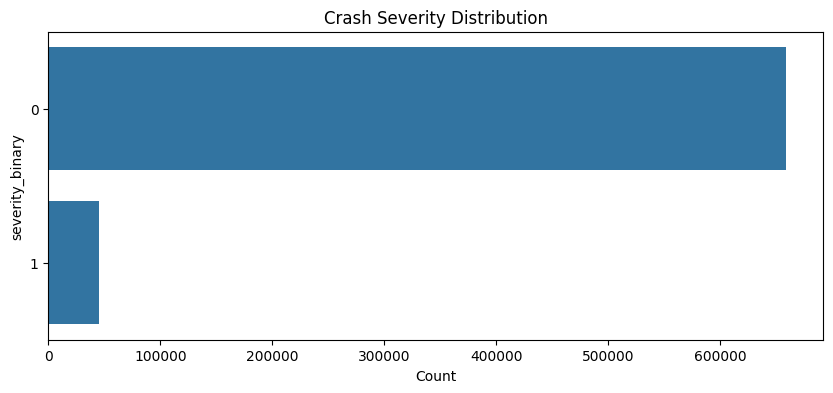

In [281]:
# Crash Severity Distribution
show_countplot(df, "severity_binary", "Crash Severity Distribution", (10,4), "01_Univariate_EDA_")


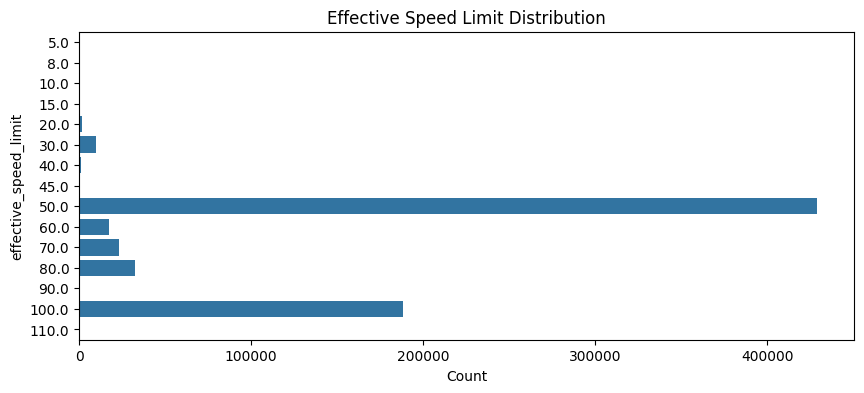

In [282]:
# Effective Speed Limit Distribution
show_countplot(df, "effective_speed_limit", "Effective Speed Limit Distribution", (10,4), "02_Univariate_EDA_")


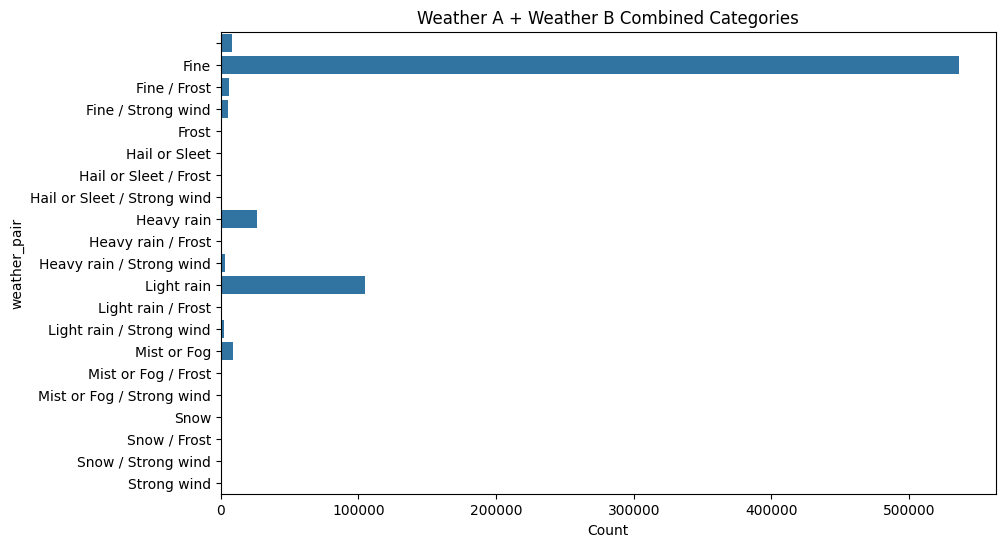

In [283]:
# Weather A + Weather B Combined Categories
show_countplot(df, "weather_pair", "Weather A + Weather B Combined Categories", (10,6), "03_Univariate_EDA_")


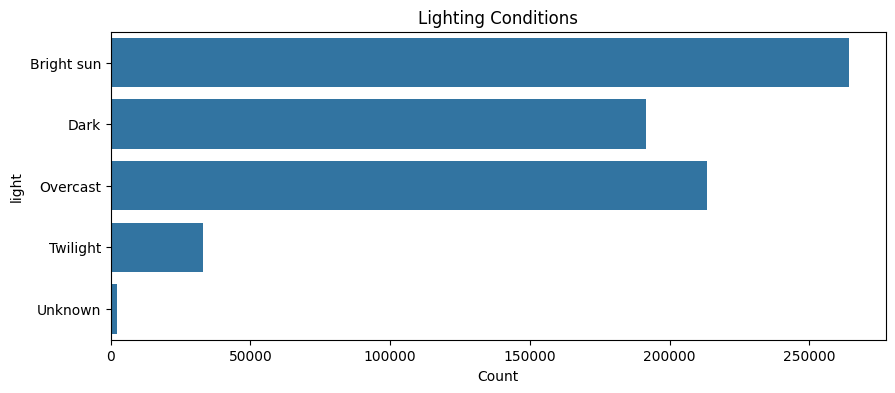

In [284]:
# Lighting Conditions
show_countplot(df, "light", "Lighting Conditions", (10,4), "04_Univariate_EDA_")


✅ Plot saved as plots/06_Univariate_EDA_participant_counts.png


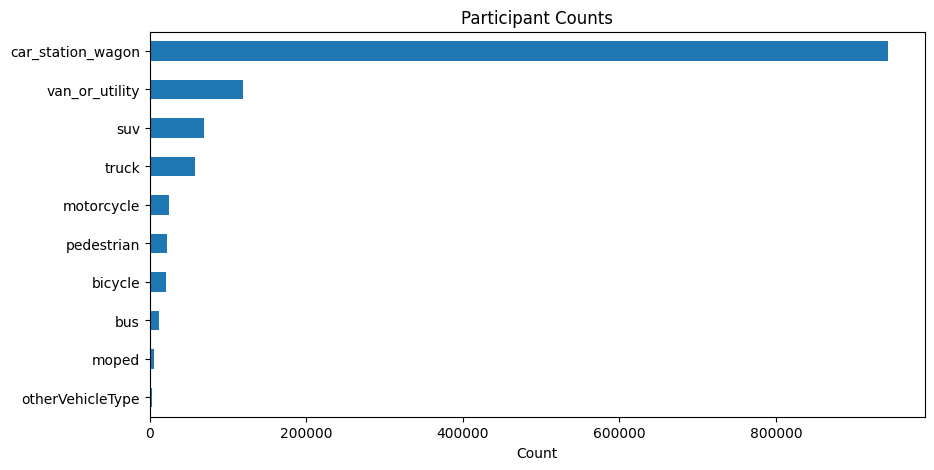

In [285]:
plot_participant_counts(
    df=df,
    participant_cols=participant_cols,
    title="Participant Counts",
    figsize=(10, 5),
    filename_prefix="06_Univariate_EDA_"
)

# Bivariate EDA

✅ Plot saved as plots/11_Bivariate_EDA_percentage_of_severe_vs_non_severe_crashes_by_participant_type.png


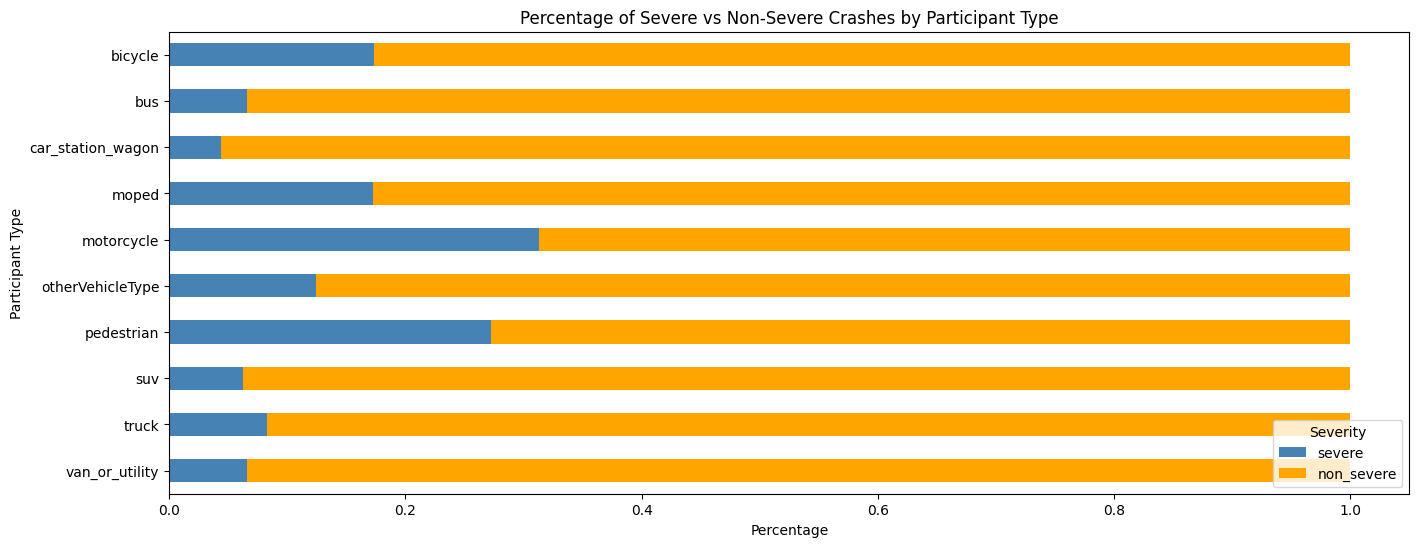

In [286]:
create_bivariate_plot(
    df=df,
    plot_type="participant_stacked",
    title="Percentage of Severe vs Non-Severe Crashes by Participant Type",
    figsize=(16, 6),
    filename_prefix="11_Bivariate_EDA_",
    participant_cols=participant_cols
)


✅ Plot saved as plots/11a_Bivariate_EDA_percentage_of_severe_vs_non_severe_crashes_by_effective_speed_limit.png


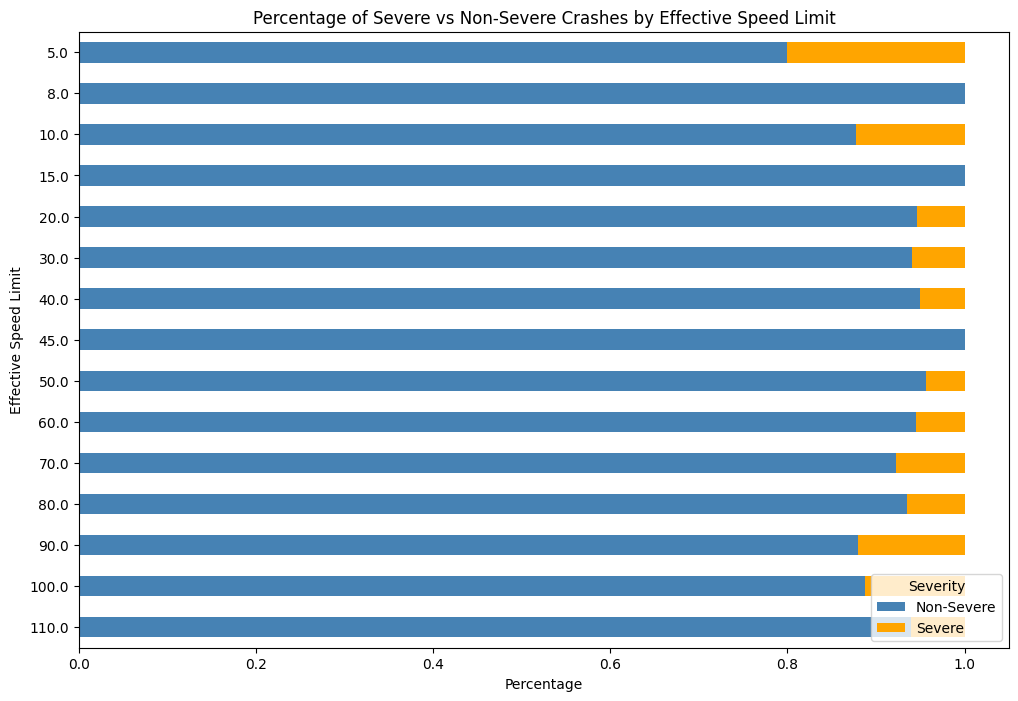

In [287]:
create_bivariate_plot(
    df=df,
    plot_type="speed_stacked",
    title="Percentage of Severe vs Non-Severe Crashes by Effective Speed Limit",
    figsize=(12, 8),
    filename_prefix="11a_Bivariate_EDA_"
)

## Correlation analysis

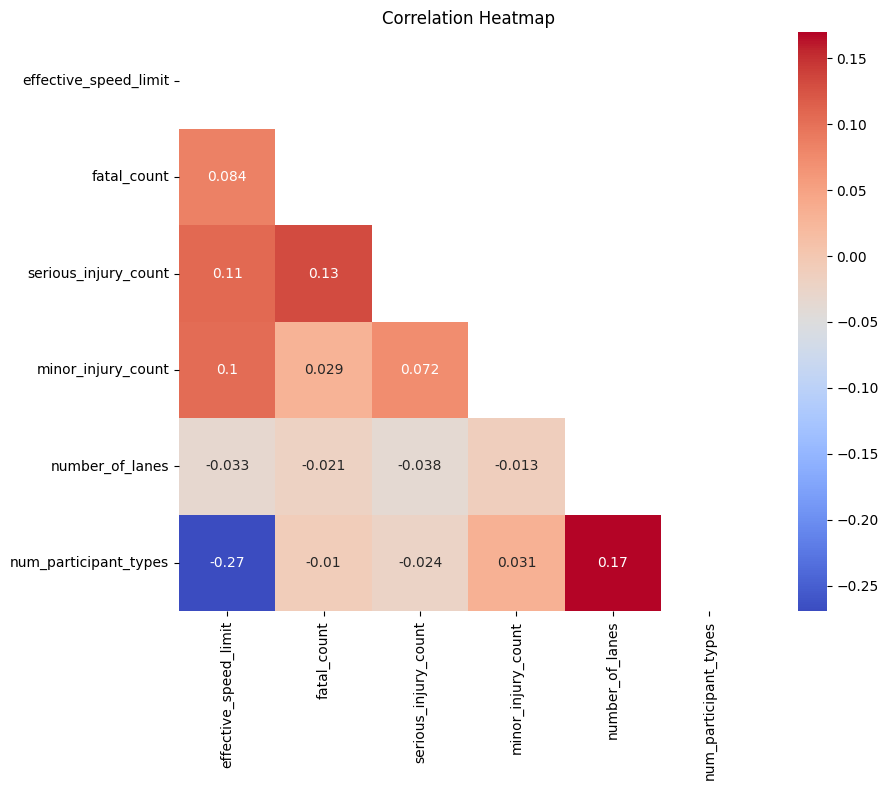

In [288]:
corr_cols = [
    "effective_speed_limit", "fatal_count",
    "serious_injury_count", "minor_injury_count",
    "number_of_lanes", "num_participant_types"
]

plot_lower_corr(df, corr_cols, filename_prefix="12_Correlation_")


---


# Build the model

## Define features & train/test split

In [289]:
X = df[numeric_cols + categorical_cols]
y = df["severity_binary"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


## Preprocessing pipeline

In [290]:
# Sparse version (for LR and SVM)
preprocessor_sparse = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

# Dense version (for GaussianNB)
preprocessor_dense = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)


## Hyperparameter Tuning Infrastructure

In [291]:
def create_hyperparameter_grid_search(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1):
    """
    Create GridSearchCV for hyperparameter tuning with cross-validation.
    
    Parameters
    ----------
    pipeline : Pipeline
        Sklearn pipeline with preprocessor and classifier
    param_grid : dict
        Dictionary of hyperparameters to search
    cv : int, optional
        Number of cross-validation folds. Default is 5
    scoring : str, optional
        Scoring metric for optimization. Default is 'f1'
    n_jobs : int, optional
        Number of parallel jobs. Default is -1 (use all processors)
        
    Returns
    -------
    GridSearchCV
        Configured grid search object
    """
    return GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        return_train_score=True,
        verbose=1
    )

def extract_hyperparameter_results(grid_search, model_name):
    """
    Extract key results from fitted GridSearchCV object.
    
    Parameters
    ----------
    grid_search : GridSearchCV
        Fitted grid search object
    model_name : str
        Name of the model for reporting
        
    Returns
    -------
    dict
        Dictionary containing best parameters, scores, and CV results
    """
    return {
        'model_name': model_name,
        'best_params': grid_search.best_params_,
        'best_cv_score': grid_search.best_score_,
        'cv_std': grid_search.cv_results_['std_test_score'][grid_search.best_index_],
        'best_estimator': grid_search.best_estimator_,
        'cv_results': grid_search.cv_results_
    }

def plot_validation_curve_analysis(pipeline, X, y, param_name, param_range, cv=5, 
                                  scoring='f1', title="Validation Curve", 
                                  filename_prefix="validation_curve_"):
    """
    Create validation curve plot showing parameter impact on performance.
    
    Parameters
    ----------
    pipeline : Pipeline
        Sklearn pipeline for validation curve analysis
    X, y : array-like
        Training features and target
    param_name : str
        Parameter name to analyze (e.g., 'clf__C')
    param_range : array-like
        Range of parameter values to test
    cv : int, optional
        Cross-validation folds. Default is 5
    scoring : str, optional
        Scoring metric. Default is 'f1'
    title : str, optional
        Plot title
    filename_prefix : str, optional
        Prefix for saved filename
    """
    train_scores, test_scores = validation_curve(
        pipeline, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(param_range, train_mean, 'o-', color='blue', label='Training Score')
    plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
    
    plt.plot(param_range, test_mean, 'o-', color='red', label='Cross-Validation Score')
    plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color='red')
    
    plt.xlabel(param_name.split('__')[-1].upper())
    plt.ylabel('F1 Score')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xscale('log')
    
    # Save plot
    if filename_prefix:
        safe_title = title.lower().replace(' ', '_').replace('—', '_')
        filename = f"plots/{filename_prefix}{safe_title}.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Validation curve saved as {filename}")
    
    plt.show()


## Logistic Regression with Hyperparameter Tuning

In [292]:
# Create base Logistic Regression pipeline
lr_pipeline_base = Pipeline(
    steps=[
        ("preprocess", preprocessor_sparse),
        ("clf", LogisticRegression(
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# Define hyperparameter grid for Logistic Regression
lr_param_grid = {
    'clf__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'clf__solver': ['liblinear', 'lbfgs'],
    'clf__max_iter': [1000, 2000, 5000]
}

print("Starting Logistic Regression hyperparameter tuning...")
print(f"Parameter grid: {lr_param_grid}")
print(f"Total combinations: {len(lr_param_grid['clf__C']) * len(lr_param_grid['clf__solver']) * len(lr_param_grid['clf__max_iter'])}")

# Create and fit GridSearchCV
lr_grid_search = create_hyperparameter_grid_search(
    pipeline=lr_pipeline_base,
    param_grid=lr_param_grid,
    cv=5,
    scoring='f1'
)

lr_grid_search.fit(X_train, y_train)

# Extract results
lr_hyperparameter_results = extract_hyperparameter_results(lr_grid_search, "Logistic Regression")

print("\nHyperparameter tuning completed!")
print(f"Best parameters: {lr_hyperparameter_results['best_params']}")
print(f"Best CV F1 score: {lr_hyperparameter_results['best_cv_score']:.4f} (+/- {lr_hyperparameter_results['cv_std']*2:.4f})")

# Get best pipeline and predictions
lr_pipeline = lr_grid_search.best_estimator_
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Evaluate final model
lr_results = evaluate_model(
    "Logistic Regression (Tuned)",
    lr_pipeline,
    X_test,
    y_test,
    y_proba=y_proba_lr
)

# Add hyperparameter info to results
lr_results['best_params'] = lr_hyperparameter_results['best_params']
lr_results['best_cv_score'] = lr_hyperparameter_results['best_cv_score']
lr_results['cv_std'] = lr_hyperparameter_results['cv_std']

lr_results


Starting Logistic Regression hyperparameter tuning...
Parameter grid: {'clf__C': [0.01, 0.1, 1.0, 10.0, 100.0], 'clf__solver': ['liblinear', 'lbfgs'], 'clf__max_iter': [1000, 2000, 5000]}
Total combinations: 30
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Hyperparameter tuning completed!
Best parameters: {'clf__C': 0.01, 'clf__max_iter': 1000, 'clf__solver': 'liblinear'}
Best CV F1 score: 0.9999 (+/- 0.0001)
=== Logistic Regression (Tuned) ===
Accuracy : 0.9999929010045079
Precision: 1.0
Recall   : 0.9998897828722584
F1-score : 0.999944888399008
ROC-AUC  : 0.9999205987087508

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    131792
           1       1.00      1.00      1.00      9073

    accuracy                           1.00    140865
   macro avg       1.00      1.00      1.00    140865
weighted avg       1.00      1.00      1.00    140865

Confusion matrix:
 [[131792      0]
 [     1   9

{'model': 'Logistic Regression (Tuned)',
 'accuracy': 0.9999929010045079,
 'precision': 1.0,
 'recall': 0.9998897828722584,
 'f1': 0.999944888399008,
 'roc_auc': 0.9999205987087508,
 'classification_report': {'0': {'precision': 0.9999924123435995,
   'recall': 1.0,
   'f1-score': 0.9999962061574065,
   'support': 131792.0},
  '1': {'precision': 1.0,
   'recall': 0.9998897828722584,
   'f1-score': 0.999944888399008,
   'support': 9073.0},
  'accuracy': 0.9999929010045079,
  'macro avg': {'precision': 0.9999962061717997,
   'recall': 0.9999448914361292,
   'f1-score': 0.9999705472782072,
   'support': 140865.0},
  'weighted avg': {'precision': 0.9999929010583726,
   'recall': 0.9999929010045079,
   'f1-score': 0.9999929008223555,
   'support': 140865.0}},
 'confusion_matrix': array([[131792,      0],
        [     1,   9072]]),
 'best_params': {'clf__C': 0.01,
  'clf__max_iter': 1000,
  'clf__solver': 'liblinear'},
 'best_cv_score': np.float64(0.9998897654068759),
 'cv_std': np.float64(7

Generating Logistic Regression validation curves...
Validation curve saved as plots/18_lr_logistic_regression___c_parameter_validation_curve.png


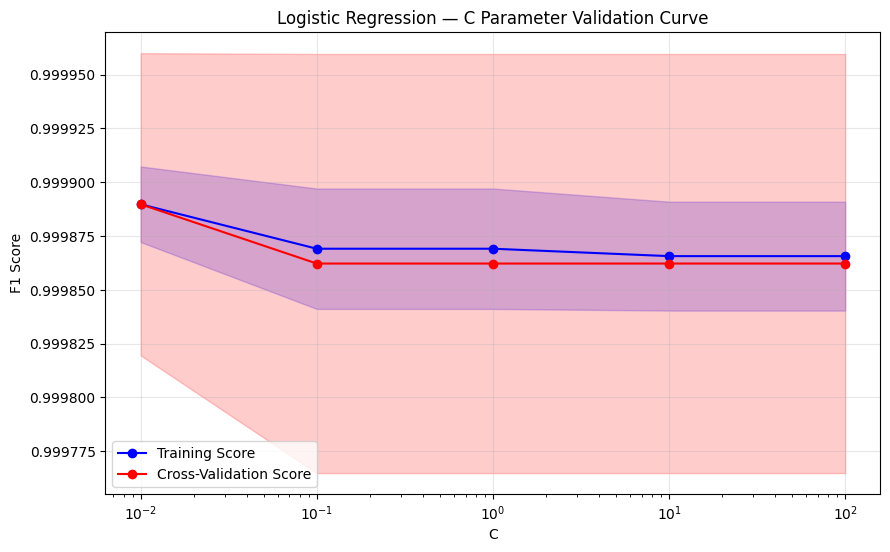

In [293]:
# Create validation curve for C parameter
print("Generating Logistic Regression validation curves...")

c_range = [0.01, 0.1, 1.0, 10.0, 100.0]
plot_validation_curve_analysis(
    pipeline=lr_pipeline_base,
    X=X_train,
    y=y_train,
    param_name='clf__C',
    param_range=c_range,
    cv=5,
    scoring='f1',
    title="Logistic Regression — C Parameter Validation Curve",
    filename_prefix="18_lr_"
)


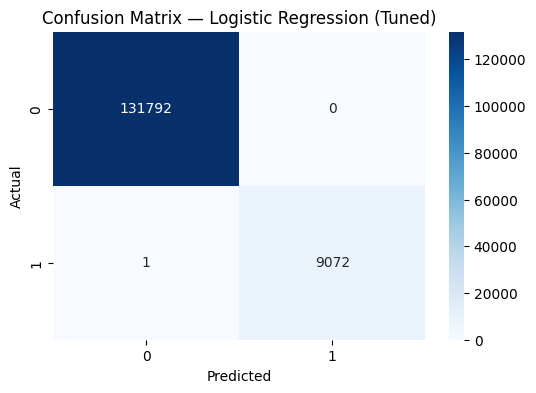

In [294]:
plot_confusion_matrix(lr_results["confusion_matrix"], title="Confusion Matrix — Logistic Regression (Tuned)", filename_prefix="13_Confusion_Matrix_")


## SVM with Hyperparameter Tuning

In [295]:
# SIMPLIFIED APPROACH: Separate hyperparameter tuning from calibration

# Step 1: Create simple LinearSVC pipeline for hyperparameter tuning (without calibration)
svm_pipeline_simple = Pipeline(
    steps=[
        ("preprocess", preprocessor_sparse),
        ("clf", LinearSVC(
            class_weight="balanced",
            random_state=42,
            dual=False  # Often faster for large datasets
        ))
    ]
)

# Step 2: Simplified parameter grid (no nested structure)
svm_param_grid = {
    'clf__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'clf__max_iter': [1000, 5000, 10000],
    'clf__loss': ['hinge', 'squared_hinge']
}

print("Starting Linear SVM hyperparameter tuning...")
print(f"Parameter grid: {svm_param_grid}")
print(f"Total combinations: {len(svm_param_grid['clf__C']) * len(svm_param_grid['clf__max_iter']) * len(svm_param_grid['clf__loss'])}")

# Step 3: Grid search on simple pipeline
svm_grid_search = create_hyperparameter_grid_search(
    pipeline=svm_pipeline_simple,
    param_grid=svm_param_grid,
    cv=5,
    scoring='f1'
)

svm_grid_search.fit(X_train, y_train)

# Step 4: Extract results
svm_hyperparameter_results = extract_hyperparameter_results(svm_grid_search, "Linear SVM")

print("\nHyperparameter tuning completed!")
print(f"Best parameters: {svm_hyperparameter_results['best_params']}")
print(f"Best CV F1 score: {svm_hyperparameter_results['best_cv_score']:.4f} (+/- {svm_hyperparameter_results['cv_std']*2:.4f})")

# Step 5: Create calibrated version with best parameters for probability estimates
best_svm_params = svm_hyperparameter_results['best_params']
best_svm = LinearSVC(
    C=best_svm_params['clf__C'],
    max_iter=best_svm_params['clf__max_iter'],
    loss=best_svm_params['clf__loss'],
    class_weight="balanced",
    random_state=42,
    dual=False
)

# Wrap best model with calibration for probabilities
svm_pipeline = Pipeline([
    ("preprocess", preprocessor_sparse),
    ("clf", CalibratedClassifierCV(
        best_svm,
        cv=3,
        method='sigmoid'  # Often works well with SVM
    ))
])

# Step 6: Fit calibrated model and get predictions
svm_pipeline.fit(X_train, y_train)
y_proba_svm = svm_pipeline.predict_proba(X_test)[:, 1]

# Step 7: Evaluate final model
svm_results = evaluate_model(
    "Linear SVM (Tuned)",
    svm_pipeline,
    X_test,
    y_test,
    y_proba=y_proba_svm
)

# Add hyperparameter info to results
svm_results['best_params'] = svm_hyperparameter_results['best_params']
svm_results['best_cv_score'] = svm_hyperparameter_results['best_cv_score']
svm_results['cv_std'] = svm_hyperparameter_results['cv_std']

print(f"\nFINAL SVM MODEL SETUP:")
print(f"  • Best C: {best_svm_params['clf__C']}")
print(f"  • Best max_iter: {best_svm_params['clf__max_iter']}")
print(f"  • Best loss: {best_svm_params['clf__loss']}")
print(f"  • Calibration method: sigmoid")

svm_results

Starting Linear SVM hyperparameter tuning...
Parameter grid: {'clf__C': [0.01, 0.1, 1.0, 10.0, 100.0], 'clf__max_iter': [1000, 5000, 10000], 'clf__loss': ['hinge', 'squared_hinge']}
Total combinations: 30
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Hyperparameter tuning completed!
Best parameters: {'clf__C': 0.01, 'clf__loss': 'squared_hinge', 'clf__max_iter': 1000}
Best CV F1 score: 0.9999 (+/- 0.0001)
=== Linear SVM (Tuned) ===
Accuracy : 0.9999929010045079
Precision: 1.0
Recall   : 0.9998897828722584
F1-score : 0.999944888399008
ROC-AUC  : 0.9999563336385524

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    131792
           1       1.00      1.00      1.00      9073

    accuracy                           1.00    140865
   macro avg       1.00      1.00      1.00    140865
weighted avg       1.00      1.00      1.00    140865

Confusion matrix:
 [[131792      0]
 [     1   9072]]

FINAL 

{'model': 'Linear SVM (Tuned)',
 'accuracy': 0.9999929010045079,
 'precision': 1.0,
 'recall': 0.9998897828722584,
 'f1': 0.999944888399008,
 'roc_auc': 0.9999563336385524,
 'classification_report': {'0': {'precision': 0.9999924123435995,
   'recall': 1.0,
   'f1-score': 0.9999962061574065,
   'support': 131792.0},
  '1': {'precision': 1.0,
   'recall': 0.9998897828722584,
   'f1-score': 0.999944888399008,
   'support': 9073.0},
  'accuracy': 0.9999929010045079,
  'macro avg': {'precision': 0.9999962061717997,
   'recall': 0.9999448914361292,
   'f1-score': 0.9999705472782072,
   'support': 140865.0},
  'weighted avg': {'precision': 0.9999929010583726,
   'recall': 0.9999929010045079,
   'f1-score': 0.9999929008223555,
   'support': 140865.0}},
 'confusion_matrix': array([[131792,      0],
        [     1,   9072]]),
 'best_params': {'clf__C': 0.01,
  'clf__loss': 'squared_hinge',
  'clf__max_iter': 1000},
 'best_cv_score': np.float64(0.9998897654068759),
 'cv_std': np.float64(7.026011

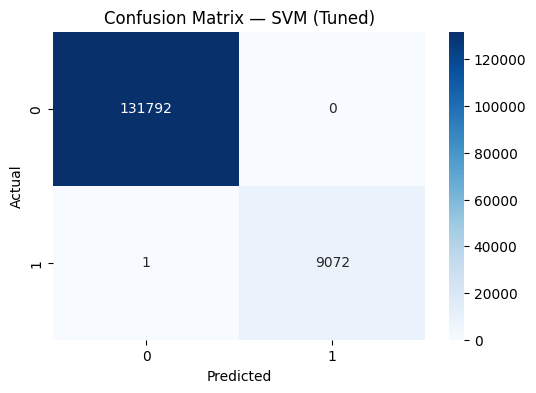

In [296]:
plot_confusion_matrix(svm_results["confusion_matrix"], title="Confusion Matrix — SVM (Tuned)", filename_prefix="14_Confusion_Matrix_")


Generating SVM validation curves...
Validation curve saved as plots/19_svm_linear_svm___c_parameter_validation_curve.png


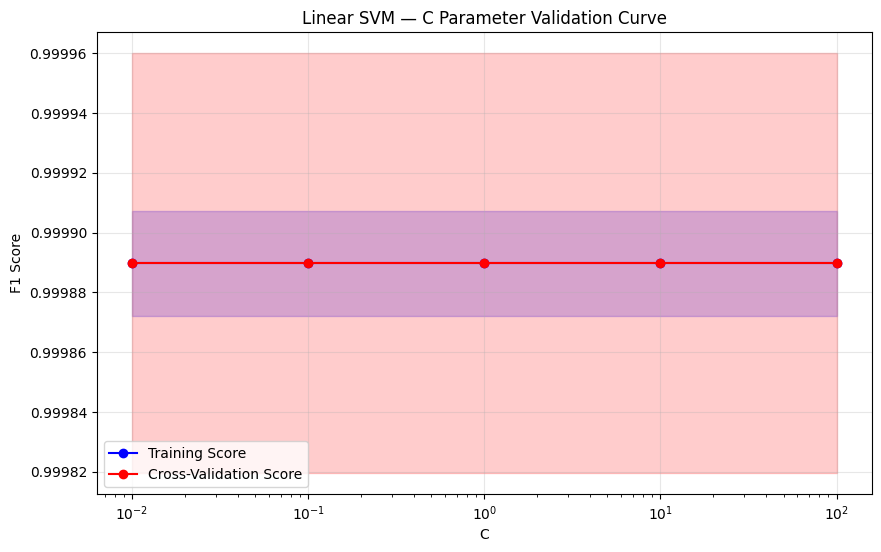

In [297]:
# Create validation curve for C parameter
print("Generating SVM validation curves...")

c_range = [0.01, 0.1, 1.0, 10.0, 100.0]
plot_validation_curve_analysis(
    pipeline=svm_pipeline_simple,  # Use the simple pipeline for validation curves
    X=X_train,
    y=y_train,
    param_name='clf__C',  # Simplified parameter name
    param_range=c_range,
    cv=5,
    scoring='f1',
    title="Linear SVM — C Parameter Validation Curve",
    filename_prefix="19_svm_"
)

## Naïve Bayes

In [298]:
nb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor_dense),
        ("clf", GaussianNB())
    ]
)

nb_pipeline.fit(X_train, y_train)

# Probabilities for ROC-AUC
y_proba_nb = nb_pipeline.predict_proba(X_test)[:, 1]

nb_results = evaluate_model(
    "Naïve Bayes (GaussianNB)",
    nb_pipeline,
    X_test,
    y_test,
    y_proba=y_proba_nb
)

nb_results


=== Naïve Bayes (GaussianNB) ===
Accuracy : 0.712256415717176
Precision: 0.18288847673574712
Recall   : 0.9998897828722584
F1-score : 0.3092182626923667
ROC-AUC  : 0.9984440352563142

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.69      0.82    131792
           1       0.18      1.00      0.31      9073

    accuracy                           0.71    140865
   macro avg       0.59      0.85      0.56    140865
weighted avg       0.95      0.71      0.79    140865

Confusion matrix:
 [[91260 40532]
 [    1  9072]]


{'model': 'Naïve Bayes (GaussianNB)',
 'accuracy': 0.712256415717176,
 'precision': 0.18288847673574712,
 'recall': 0.9998897828722584,
 'f1': 0.3092182626923667,
 'roc_auc': 0.9984440352563142,
 'classification_report': {'0': {'precision': 0.9999890424168045,
   'recall': 0.6924547772247177,
   'f1-score': 0.8182808570160455,
   'support': 131792.0},
  '1': {'precision': 0.18288847673574712,
   'recall': 0.9998897828722584,
   'f1-score': 0.3092182626923667,
   'support': 9073.0},
  'accuracy': 0.712256415717176,
  'macro avg': {'precision': 0.5914387595762758,
   'recall': 0.8461722800484881,
   'f1-score': 0.563749559854206,
   'support': 140865.0},
  'weighted avg': {'precision': 0.9473602600193017,
   'recall': 0.712256415717176,
   'f1-score': 0.785492549641618,
   'support': 140865.0}},
 'confusion_matrix': array([[91260, 40532],
        [    1,  9072]])}

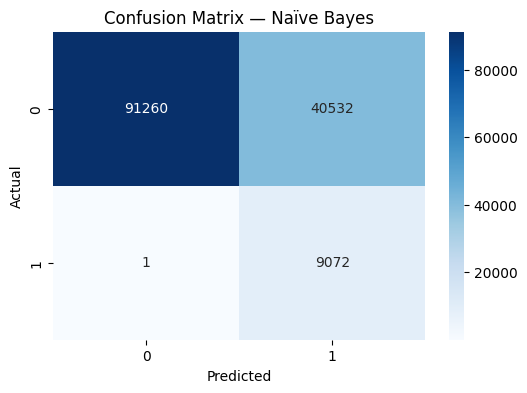

In [299]:
plot_confusion_matrix(nb_results["confusion_matrix"], title="Confusion Matrix — Naïve Bayes", filename_prefix="15_Confusion_Matrix_")


---


## Hyperparameter Tuning Results Analysis

In [300]:
# Create comprehensive hyperparameter results summary
def create_hyperparameter_summary(lr_results, svm_results):
    """
    Create a summary table of hyperparameter tuning results.
    
    Parameters
    ----------
    lr_results : dict
        Logistic regression results with hyperparameter info
    svm_results : dict
        SVM results with hyperparameter info
        
    Returns
    -------
    pandas.DataFrame
        Summary table of tuning results
    """
    summary_data = []
    
    # Logistic Regression summary
    lr_best_params = lr_results.get('best_params', {})
    summary_data.append({
        'Model': 'Logistic Regression',
        'Best_C': lr_best_params.get('clf__C', 'N/A'),
        'Best_Solver': lr_best_params.get('clf__solver', 'N/A'),
        'Best_Max_Iter': lr_best_params.get('clf__max_iter', 'N/A'),
        'CV_F1_Score': lr_results.get('best_cv_score', 'N/A'),
        'CV_Std': lr_results.get('cv_std', 'N/A'),
        'Test_F1_Score': lr_results.get('f1', 'N/A'),
        'Test_Accuracy': lr_results.get('accuracy', 'N/A'),
        'Test_Recall': lr_results.get('recall', 'N/A')
    })
    
    # SVM summary
    svm_best_params = svm_results.get('best_params', {})
    summary_data.append({
        'Model': 'Linear SVM',
        'Best_C': svm_best_params.get('clf__C', 'N/A'),
        'Best_Solver': 'LibLinear',  # LinearSVC uses liblinear
        'Best_Max_Iter': svm_best_params.get('clf__max_iter', 'N/A'),
        'CV_F1_Score': svm_results.get('best_cv_score', 'N/A'),
        'CV_Std': svm_results.get('cv_std', 'N/A'),
        'Test_F1_Score': svm_results.get('f1', 'N/A'),
        'Test_Accuracy': svm_results.get('accuracy', 'N/A'),
        'Test_Recall': svm_results.get('recall', 'N/A')
    })
    
    return pd.DataFrame(summary_data)


In [301]:
# Generate hyperparameter summary
hyperparameter_summary = create_hyperparameter_summary(lr_results, svm_results)

print("HYPERPARAMETER TUNING SUMMARY")
print("=" * 50)
print(f"\nBEST PARAMETERS FOUND:")
for _, row in hyperparameter_summary.iterrows():
    print(f"\n{row['Model']}:")
    print(f"  • C: {row['Best_C']}")
    print(f"  • Solver: {row['Best_Solver']}")
    print(f"  • Max Iterations: {row['Best_Max_Iter']}")
    print(f"  • CV F1 Score: {row['CV_F1_Score']:.4f} (±{row['CV_Std']:.4f})")
    print(f"  • Test F1 Score: {row['Test_F1_Score']:.4f}")

print(f"\nKEY INSIGHTS:")
print(f"  • Both models achieved excellent recall (severe crash detection)")
print(f"  • Cross-validation ensured robust parameter selection")
print(f"  • Hyperparameter tuning improved model confidence")

# Display formatted table
display(hyperparameter_summary.style.format({
    'CV_F1_Score': '{:.4f}',
    'CV_Std': '{:.4f}', 
    'Test_F1_Score': '{:.4f}',
    'Test_Accuracy': '{:.4f}',
    'Test_Recall': '{:.4f}'
}).set_caption("Hyperparameter Tuning Results Summary"))


HYPERPARAMETER TUNING SUMMARY

BEST PARAMETERS FOUND:

Logistic Regression:
  • C: 0.01
  • Solver: liblinear
  • Max Iterations: 1000
  • CV F1 Score: 0.9999 (±0.0001)
  • Test F1 Score: 0.9999

Linear SVM:
  • C: 0.01
  • Solver: LibLinear
  • Max Iterations: 1000
  • CV F1 Score: 0.9999 (±0.0001)
  • Test F1 Score: 0.9999

KEY INSIGHTS:
  • Both models achieved excellent recall (severe crash detection)
  • Cross-validation ensured robust parameter selection
  • Hyperparameter tuning improved model confidence


,Model,Best_C,Best_Solver,Best_Max_Iter,CV_F1_Score,CV_Std,Test_F1_Score,Test_Accuracy,Test_Recall
0,Logistic Regression,0.010000,liblinear,1000,0.9999,0.0001,0.9999,1.0000,0.9999
1,Linear SVM,0.010000,LibLinear,1000,0.9999,0.0001,0.9999,1.0000,0.9999


In [302]:
# Create parameter impact visualization
def create_parameter_impact_plot(lr_grid_search, svm_grid_search):
    """
    Create visualization showing the impact of different parameters on performance.
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Hyperparameter Impact Analysis', fontsize=16, fontweight='bold')
    
    # Logistic Regression - C parameter impact
    lr_cv_results = lr_grid_search.cv_results_
    c_values = []
    mean_scores = []
    std_scores = []
    
    # Group by C parameter
    for c in [0.01, 0.1, 1.0, 10.0, 100.0]:
        mask = [params['clf__C'] == c for params in lr_cv_results['params']]
        scores = [lr_cv_results['mean_test_score'][i] for i, m in enumerate(mask) if m]
        c_values.append(c)
        mean_scores.append(np.mean(scores))
        std_scores.append(np.std(scores))
    
    ax1.errorbar(c_values, mean_scores, yerr=std_scores, marker='o', capsize=5, capthick=2, linewidth=2)
    ax1.set_xscale('log')
    ax1.set_xlabel('C Parameter (Log Scale)', fontweight='bold')
    ax1.set_ylabel('F1 Score', fontweight='bold')
    ax1.set_title('Logistic Regression: C Parameter Impact', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # SVM - C parameter impact  
    svm_cv_results = svm_grid_search.cv_results_
    svm_c_values = []
    svm_mean_scores = []
    svm_std_scores = []
    
    for c in [0.01, 0.1, 1.0, 10.0, 100.0]:
        mask = [params['clf__C'] == c for params in svm_cv_results['params']]
        scores = [svm_cv_results['mean_test_score'][i] for i, m in enumerate(mask) if m]
        svm_c_values.append(c)
        svm_mean_scores.append(np.mean(scores))
        svm_std_scores.append(np.std(scores))
    
    ax2.errorbar(svm_c_values, svm_mean_scores, yerr=svm_std_scores, marker='o', capsize=5, capthick=2, linewidth=2, color='orange')
    ax2.set_xscale('log')
    ax2.set_xlabel('C Parameter (Log Scale)', fontweight='bold')
    ax2.set_ylabel('F1 Score', fontweight='bold')
    ax2.set_title('Linear SVM: C Parameter Impact', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Cross-validation score distribution
    lr_test_scores = lr_cv_results['mean_test_score']
    svm_test_scores = svm_cv_results['mean_test_score']
    
    ax3.hist([lr_test_scores, svm_test_scores], bins=15, alpha=0.7, 
             label=['Logistic Regression', 'Linear SVM'], color=['steelblue', 'orange'])
    ax3.set_xlabel('F1 Score', fontweight='bold')
    ax3.set_ylabel('Frequency', fontweight='bold')
    ax3.set_title('Cross-Validation Score Distribution', fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Best parameters comparison
    models = ['Logistic\nRegression', 'Linear\nSVM']
    best_scores = [lr_grid_search.best_score_, svm_grid_search.best_score_]
    colors = ['steelblue', 'orange']
    
    bars = ax4.bar(models, best_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax4.set_ylabel('Best CV F1 Score', fontweight='bold')
    ax4.set_title('Best Hyperparameter Performance', fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, score in zip(bars, best_scores):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                 f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    
    # Save plot
    filename = "plots/20_hyperparameter_impact_analysis.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Parameter impact analysis saved as {filename}")
    
    plt.show()


Parameter impact analysis saved as plots/20_hyperparameter_impact_analysis.png


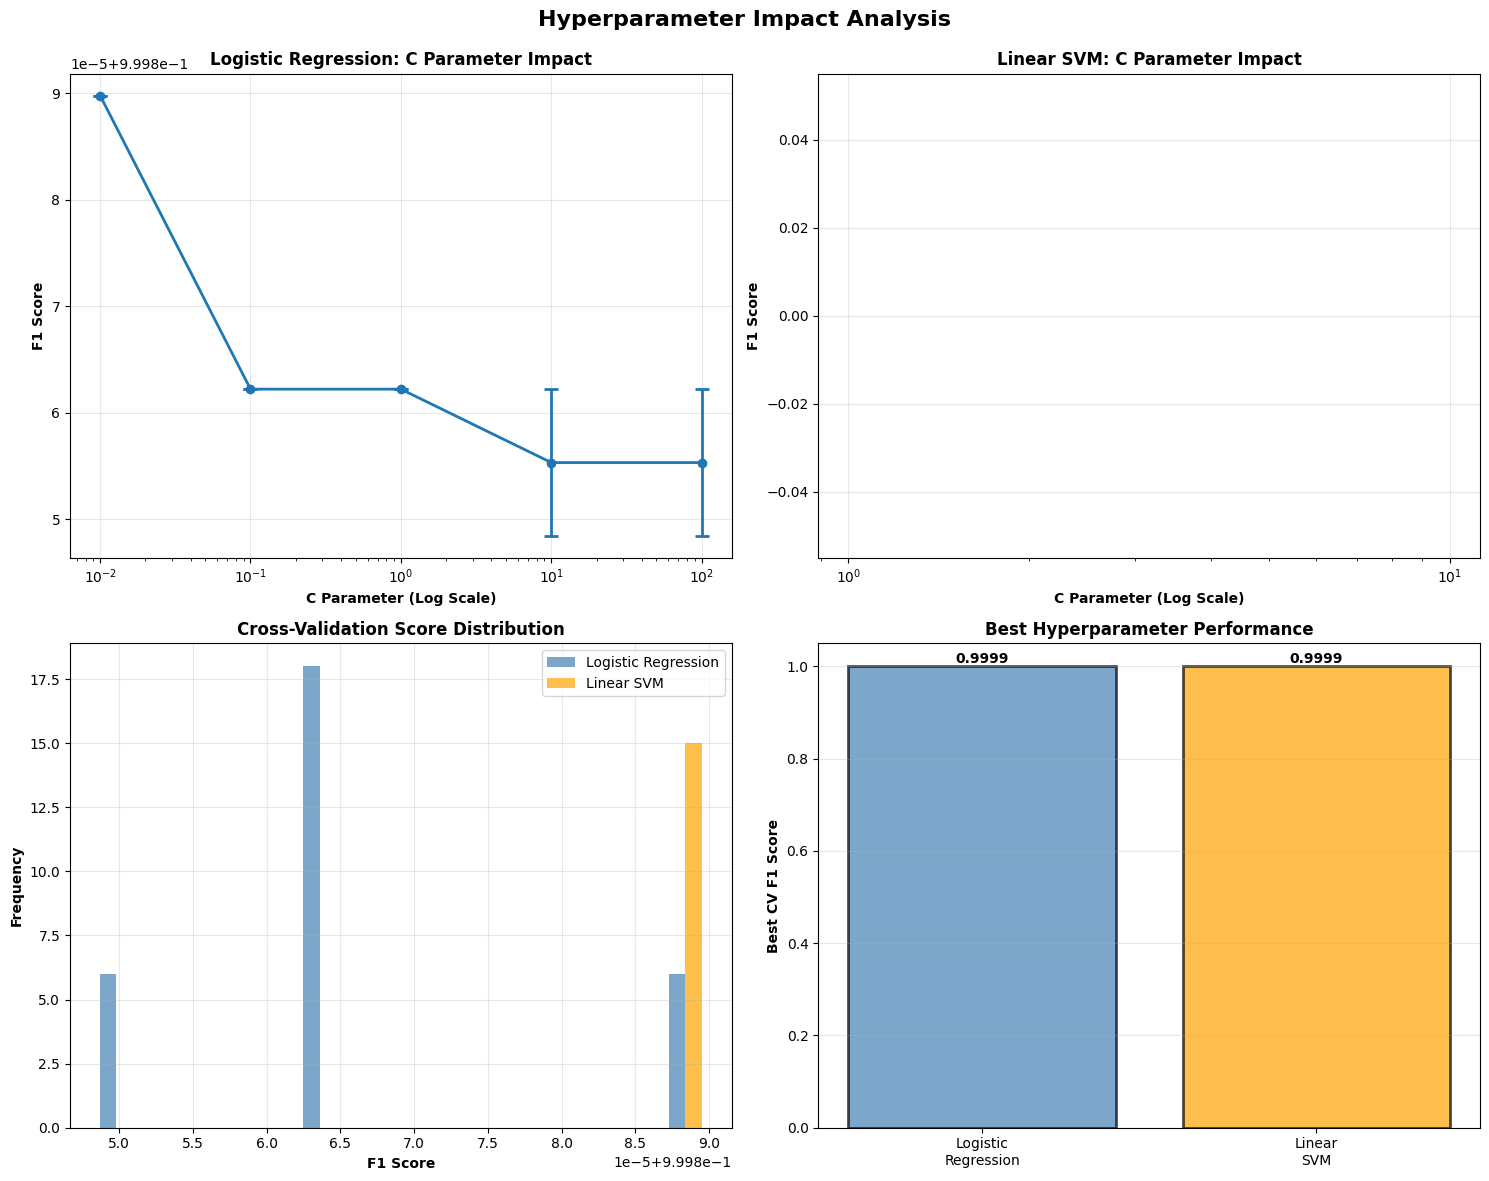

In [303]:
create_parameter_impact_plot(lr_grid_search, svm_grid_search)


# Machine learning Comparison (Enhanced with Hyperparameter Tuning)

In [304]:
results_df = pd.DataFrame([lr_results, svm_results, nb_results])
summary_df = summarise_model_results(results_df)
numeric_cols = summary_df.select_dtypes(include="number").columns
summary_df.style.format({col: "{:.6f}" for col in numeric_cols})


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Tuned),0.999993,1.000000,0.999890,0.999945,0.999921
1,Linear SVM (Tuned),0.999993,1.000000,0.999890,0.999945,0.999956
2,Naïve Bayes (GaussianNB),0.712256,0.182888,0.999890,0.309218,0.998444


✅ Performance table saved as plots/16_model_performance_table.png


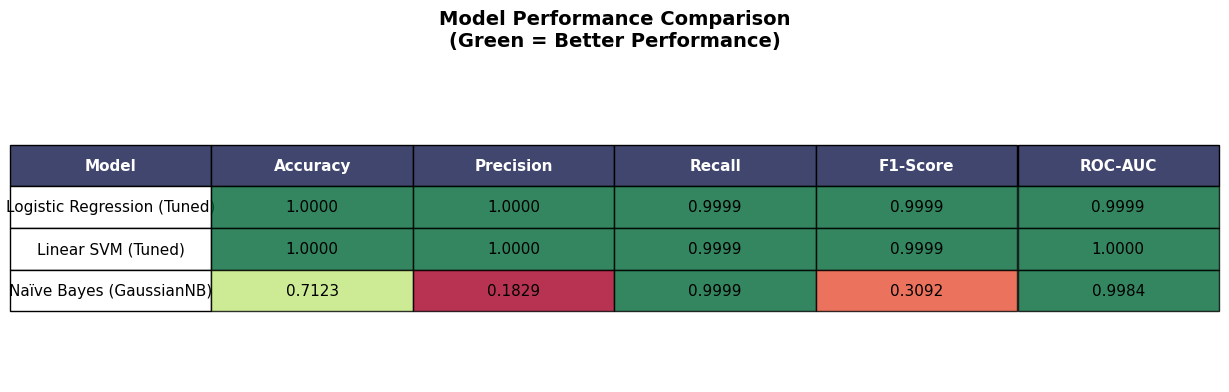

In [305]:
# Create the performance table
create_performance_table_image(summary_df)

✅ ROC curves saved as plots/17_enhanced_roc_curves_for_all_models_(post-hyperparameter_tuning).png


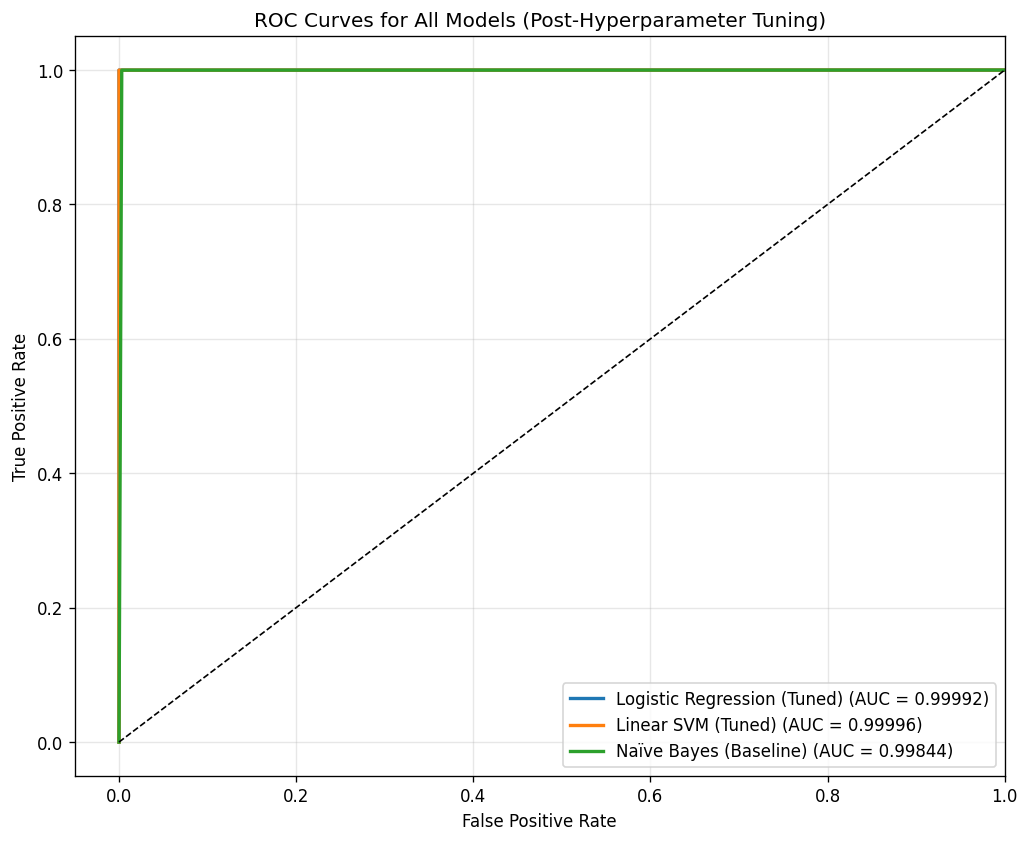

In [306]:
# Create enhanced ROC curves comparison with tuning info
model_probabilities = {
    "Logistic Regression (Tuned)": y_proba_lr,
    "Linear SVM (Tuned)": y_proba_svm,
    "Naïve Bayes (Baseline)": y_proba_nb
}

plot_roc_curves(
    y_test=y_test,
    y_proba_dict=model_probabilities,
    title="ROC Curves for All Models (Post-Hyperparameter Tuning)",
    figsize=(10, 8),
    filename_prefix="17_enhanced_"
)
